# EIT Conductivity Reconstruction

This notebook demonstrates **Electrical Impedance Tomography (EIT)** reconstruction
using three different algorithms. We load precomputed results so that every cell runs
in seconds; commented-out code at the end shows how to rerun the full pipeline from
scratch.

## Table of Contents

1. [Setup](#setup)
2. [Background: What is EIT?](#background)
3. [Physical Model](#physical-model)
4. [Data Loading](#data-loading)
5. [Mesh Visualization](#mesh-visualization)
6. [Experiment 1 -- Back-Projection (BP)](#experiment-1-bp)
7. [Experiment 2 -- GREIT](#experiment-2-greit)
8. [Experiment 3 -- JAC Dynamic](#experiment-3-jac-dynamic)
9. [Comparison of All Methods](#comparison)
10. [Quantitative Metrics](#metrics)
11. [Running from Scratch](#running-from-scratch)
12. [Summary](#summary)

In [ ]:
%matplotlib inline
import sys, os, json

# Ensure the working directory is the task root (one level above notebooks/)
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.join(os.path.dirname(os.getcwd()), '.'))
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt

from src.preprocessing import prepare_data
from src.physics_model import PyEITMesh, PyEITProtocol, EITForwardModel, sim2pts
from src.solvers import BPReconstructor, GREITReconstructor, JACDynamicReconstructor
from src.visualization import compute_metrics, print_metrics_table

REF_DIR = 'evaluation/reference_outputs'
print(f'Working directory: {os.getcwd()}')

<a id="background"></a>
## 2. Background: What is EIT?

**Electrical Impedance Tomography (EIT)** is a non-invasive imaging technique that
reconstructs the internal conductivity distribution of a body from electrical
measurements taken at its boundary.

The basic procedure is:

1. Attach electrodes around the boundary of the object.
2. Inject small currents through pairs of electrodes.
3. Measure the resulting voltages on the remaining electrodes.
4. Use an inverse algorithm to recover the internal conductivity map.

**Applications** include:
- **Medical imaging**: lung ventilation monitoring, breast cancer detection,
  brain stroke classification.
- **Industrial inspection**: multiphase flow monitoring, concrete crack detection.
- **Geophysics**: subsurface conductivity mapping.

EIT is attractive because the hardware is inexpensive and portable, but the
reconstruction problem is severely ill-posed: small measurement noise can lead to
large errors in the recovered image. Regularization is therefore essential.

<a id="physical-model"></a>
## 3. Physical Model

### Forward Problem

Inside the domain $\Omega$, the electric potential $u$ satisfies the
**generalized Laplace equation**:

$$\nabla \cdot (\sigma \, \nabla u) = 0$$

where $\sigma(\mathbf{x})$ is the spatially varying conductivity.

We discretize $\Omega$ into a triangular **finite element mesh** and solve for the
nodal potentials given a conductivity distribution and boundary current injection
pattern. This gives us the *predicted* boundary voltages $\mathbf{v}(\sigma)$.

### Jacobian and Linearization

The **Jacobian** $\mathbf{J}$ relates small conductivity perturbations
$\delta\sigma$ to voltage changes $\delta\mathbf{v}$:

$$\delta\mathbf{v} \approx \mathbf{J} \, \delta\sigma$$

For **dynamic** (time-difference) imaging, we solve the linear system
$\delta\sigma = -\mathbf{H} \, \delta\mathbf{v}$ where $\mathbf{H}$ is a
regularized pseudo-inverse of $\mathbf{J}$.

<a id="data-loading"></a>
## 4. Data Loading

We load the mesh, excitation protocol, and voltage data for all three experiments
from the bundled `data/` directory.

In [2]:
obs, meta = prepare_data('data')
print(f"Loaded {len(obs)} arrays from raw_data.npz")
print(f"Experiments: {list(meta['experiments'].keys())}")
print()
# Show metadata for one experiment
print("BP experiment configuration:")
for k, v in meta['experiments']['bp'].items():
    print(f"  {k}: {v}")

Loaded 43 arrays from raw_data.npz
Experiments: ['bp', 'greit', 'jac_dynamic', 'jac_static']

BP experiment configuration:
  n_el: 16
  h0: 0.1
  dist_exc: 1
  step_meas: 1
  anomaly: [{'center': [0.5, 0.5], 'r': 0.1, 'perm': 10.0}]
  background: 1.0
  solver_weight: none


In [3]:
def build_model(obs, prefix):
    """Build an EITForwardModel from stored data arrays."""
    mesh = PyEITMesh(
        node=obs[f"{prefix}_node"],
        element=obs[f"{prefix}_element"],
        perm=obs[f"{prefix}_perm_background"],
        el_pos=obs[f"{prefix}_el_pos"],
        ref_node=int(obs[f"{prefix}_ref_node"]),
    )
    protocol = PyEITProtocol(
        ex_mat=obs[f"{prefix}_ex_mat"],
        meas_mat=obs[f"{prefix}_meas_mat"],
        keep_ba=obs[f"{prefix}_keep_ba"],
    )
    return mesh, protocol, EITForwardModel(mesh, protocol)

<a id="mesh-visualization"></a>
## 5. Mesh Visualization

Each experiment uses a 2-D circular domain discretized into a triangular finite
element mesh. Sixteen electrodes (red dots) are placed uniformly around the
boundary.

Nodes: 376, Elements: 686, Electrodes: 16


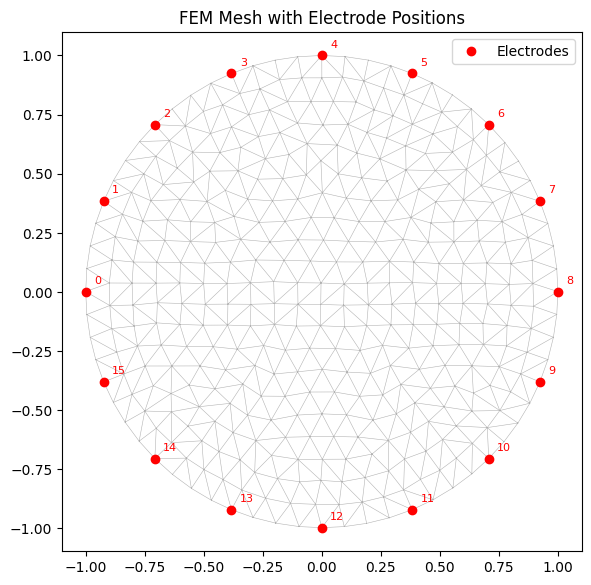

In [4]:
# Build the BP mesh to visualize
mesh_bp, _, _ = build_model(obs, 'bp')
pts = mesh_bp.node
tri = mesh_bp.element
el_pts = pts[mesh_bp.el_pos]

fig, ax = plt.subplots(figsize=(6, 6))
ax.triplot(pts[:, 0], pts[:, 1], tri, linewidth=0.4, color='gray', alpha=0.6)
ax.plot(el_pts[:, 0], el_pts[:, 1], 'ro', markersize=6, label='Electrodes')
for i in range(len(el_pts)):
    ax.annotate(str(i), (el_pts[i, 0], el_pts[i, 1]), textcoords='offset points',
                xytext=(6, 6), fontsize=8, color='red')
ax.set_aspect('equal')
ax.set_title('FEM Mesh with Electrode Positions')
ax.legend(loc='upper right')
print(f"Nodes: {pts.shape[0]}, Elements: {tri.shape[0]}, Electrodes: {len(mesh_bp.el_pos)}")
plt.tight_layout()
plt.show()

<a id="experiment-1-bp"></a>
## 6. Experiment 1 -- Back-Projection (BP)

**Back-Projection** is the simplest EIT reconstruction algorithm. It uses a
geometric "smear" matrix $\mathbf{B}$ that maps each voltage measurement back onto
the mesh nodes that contributed to it. The reconstruction is:

$$\delta\sigma = -\mathbf{B}^T \, \delta\mathbf{v}$$

This is fast and requires no matrix inversion, but produces blurry images with poor
spatial resolution.

**Setup**: A single high-conductivity anomaly ($\sigma = 10$) is placed at
$(0.5, 0.5)$ inside a unit circle with background $\sigma = 1$.

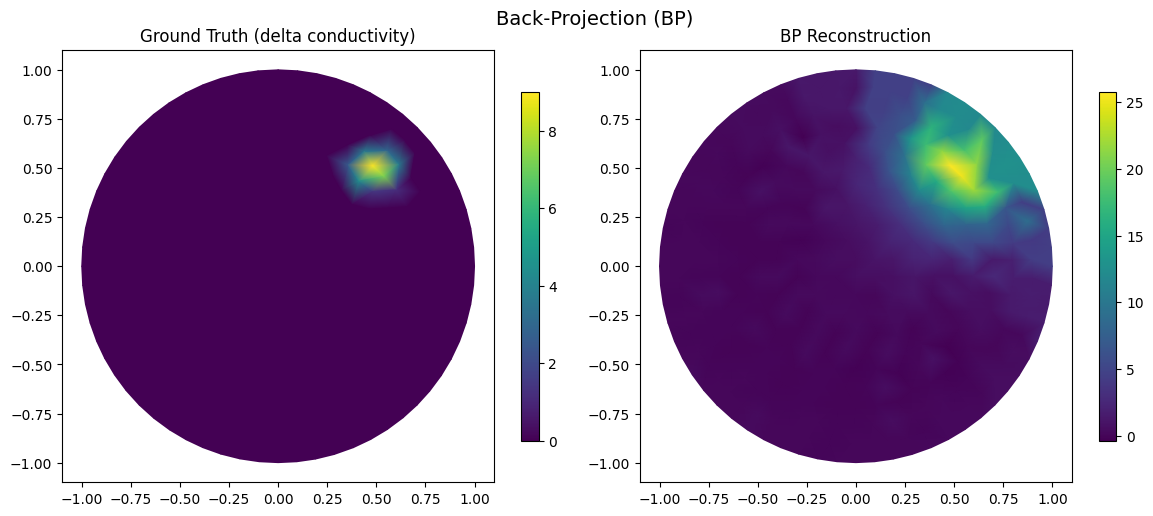

In [5]:
# Load precomputed BP results
gt_bp = np.load(os.path.join(REF_DIR, 'ground_truth_bp.npy'))
recon_bp = np.load(os.path.join(REF_DIR, 'reconstruction_bp.npy'))

mesh_bp, _, _ = build_model(obs, 'bp')
pts_bp = mesh_bp.node
tri_bp = mesh_bp.element

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Ground truth (node-level values)
im0 = axes[0].tripcolor(pts_bp[:, 0], pts_bp[:, 1], tri_bp, gt_bp, shading='gouraud', cmap='viridis')
axes[0].set_title('Ground Truth (delta conductivity)')
axes[0].set_aspect('equal')
fig.colorbar(im0, ax=axes[0], shrink=0.8)

# Reconstruction (node-level values)
im1 = axes[1].tripcolor(pts_bp[:, 0], pts_bp[:, 1], tri_bp, recon_bp, shading='gouraud', cmap='viridis')
axes[1].set_title('BP Reconstruction')
axes[1].set_aspect('equal')
fig.colorbar(im1, ax=axes[1], shrink=0.8)

plt.suptitle('Back-Projection (BP)', fontsize=14)
plt.tight_layout()
plt.show()

<a id="experiment-2-greit"></a>
## 7. Experiment 2 -- GREIT

**GREIT** (Graz consensus Reconstruction algorithm for EIT) projects the
reconstruction onto a regular pixel grid. It uses a sigmoid weighting matrix to
interpolate between the irregular FEM elements and a uniform grid, then solves
the regularized inverse problem in the grid domain:

$$\mathbf{H}_{\text{GREIT}} = \mathbf{W}^T \mathbf{J}^T (\mathbf{J}\mathbf{J}^T + \lambda \mathbf{R})^{-1}$$

This produces images that are more suitable for display and clinical interpretation.

**Setup**: Four anomalies (two high-conductivity, two low-conductivity) placed
symmetrically in a unit circle.

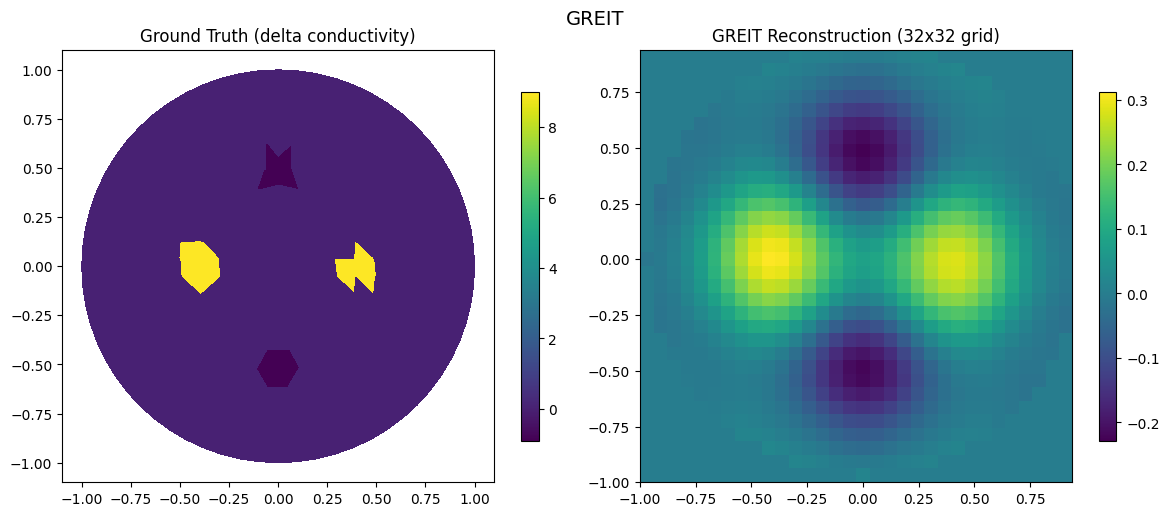

In [6]:
# Load precomputed GREIT results
gt_greit = np.load(os.path.join(REF_DIR, 'ground_truth_greit.npy'))
greit_data = np.load(os.path.join(REF_DIR, 'reconstruction_greit.npz'))
xg, yg, ds_greit = greit_data['xg'], greit_data['yg'], greit_data['ds']

mesh_greit, _, _ = build_model(obs, 'greit')
pts_greit = mesh_greit.node
tri_greit = mesh_greit.element

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Ground truth (element-level values on the mesh)
im0 = axes[0].tripcolor(pts_greit[:, 0], pts_greit[:, 1], tri_greit, gt_greit, shading='flat', cmap='viridis')
axes[0].set_title('Ground Truth (delta conductivity)')
axes[0].set_aspect('equal')
fig.colorbar(im0, ax=axes[0], shrink=0.8)

# Reconstruction (32x32 grid image)
im1 = axes[1].imshow(np.real(ds_greit), interpolation='none', cmap='viridis',
                      extent=[xg.min(), xg.max(), yg.min(), yg.max()], origin='lower')
axes[1].set_title('GREIT Reconstruction (32x32 grid)')
axes[1].set_aspect('equal')
fig.colorbar(im1, ax=axes[1], shrink=0.8)

plt.suptitle('GREIT', fontsize=14)
plt.tight_layout()
plt.show()

<a id="experiment-3-jac-dynamic"></a>
## 8. Experiment 3 -- JAC Dynamic

The **Jacobian dynamic** (time-difference) solver uses Tikhonov-style
regularization to invert the linearized forward model:

$$\mathbf{H} = (\mathbf{J}^T \mathbf{J} + \lambda \mathbf{R})^{-1} \mathbf{J}^T$$

where $\mathbf{R}$ is a regularization matrix (here Kotre weighting:
$R_{ii} = (J^T J)_{ii}^p$). The one-step linear solve gives element-level
conductivity changes.

**Setup**: A single very-high-conductivity anomaly ($\sigma = 1000$) at $(0.5, 0.5)$.

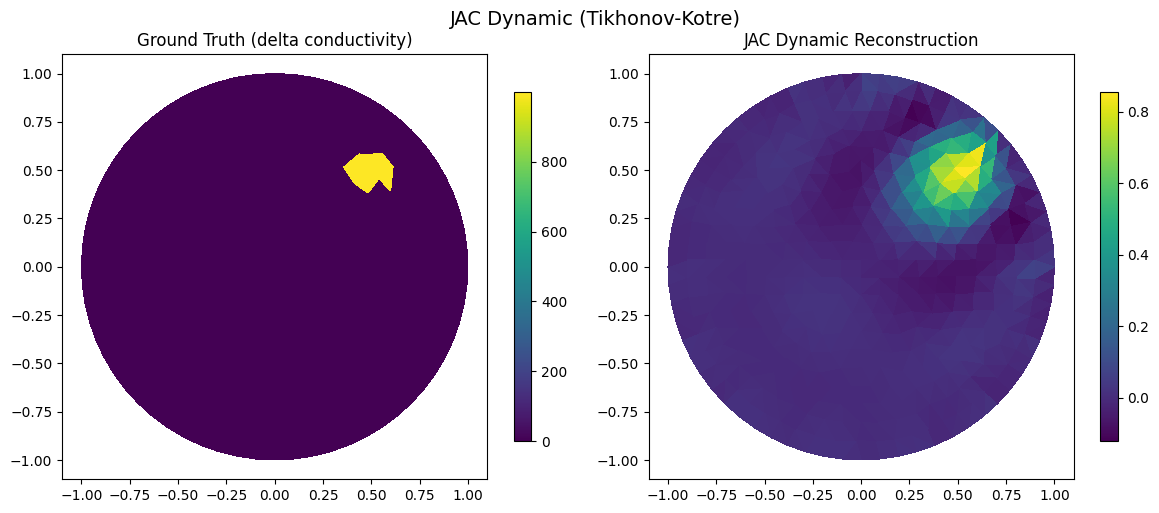

In [7]:
# Load precomputed JAC Dynamic results
gt_jac = np.load(os.path.join(REF_DIR, 'ground_truth_jac_dynamic.npy'))
recon_jac = np.load(os.path.join(REF_DIR, 'reconstruction_jac_dynamic.npy'))

mesh_jac, _, _ = build_model(obs, 'jac_dyn')
pts_jac = mesh_jac.node
tri_jac = mesh_jac.element

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Ground truth (element-level)
im0 = axes[0].tripcolor(pts_jac[:, 0], pts_jac[:, 1], tri_jac, gt_jac, shading='flat', cmap='viridis')
axes[0].set_title('Ground Truth (delta conductivity)')
axes[0].set_aspect('equal')
fig.colorbar(im0, ax=axes[0], shrink=0.8)

# Reconstruction (element-level)
im1 = axes[1].tripcolor(pts_jac[:, 0], pts_jac[:, 1], tri_jac, recon_jac, shading='flat', cmap='viridis')
axes[1].set_title('JAC Dynamic Reconstruction')
axes[1].set_aspect('equal')
fig.colorbar(im1, ax=axes[1], shrink=0.8)

plt.suptitle('JAC Dynamic (Tikhonov-Kotre)', fontsize=14)
plt.tight_layout()
plt.show()

<a id="comparison"></a>
## 9. Comparison of All Methods

Let's compare all three reconstruction methods side by side. The top row shows
ground truth conductivity distributions and the bottom row shows the
corresponding reconstructions.

In [ ]:
# Load all reference data
methods = ['bp', 'greit', 'jac_dynamic']
titles = ['Back-Projection', 'GREIT', 'JAC Dynamic']
prefixes = ['bp', 'greit', 'jac_dyn']

gts = {}
recons = {}
method_meshes = {}

for method, prefix in zip(methods, prefixes):
    gts[method] = np.load(os.path.join(REF_DIR, f'ground_truth_{method}.npy'))
    if method == 'greit':
        data = np.load(os.path.join(REF_DIR, 'reconstruction_greit.npz'))
        recons[method] = (data['xg'], data['yg'], data['ds'])
    else:
        recons[method] = np.load(os.path.join(REF_DIR, f'reconstruction_{method}.npy'))
    m, _, _ = build_model(obs, prefix)
    method_meshes[method] = m

with open(os.path.join(REF_DIR, 'metrics.json')) as f:
    all_metrics = json.load(f)

fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
fig.suptitle('EIT Reconstruction Comparison', fontsize=16)

for i, (method, title) in enumerate(zip(methods, titles)):
    m = method_meshes[method]
    pts = m.node
    tri = m.element
    gt = gts[method]
    recon = recons[method]

    # --- Ground truth row ---
    ax_gt = axes[0, i]
    if method == 'bp':
        ax_gt.tripcolor(pts[:, 0], pts[:, 1], tri, np.real(gt), shading='gouraud', cmap='viridis')
    else:
        ax_gt.tripcolor(pts[:, 0], pts[:, 1], tri, np.real(gt), shading='flat', cmap='viridis')
    ax_gt.set_title(f'{title}\nGround Truth (delta)')
    ax_gt.set_aspect('equal')

    # --- Reconstruction row ---
    ax_rec = axes[1, i]
    if method == 'greit':
        xg_m, yg_m, ds_m = recon
        ax_rec.imshow(np.real(ds_m), interpolation='none', cmap='viridis')
    elif method == 'bp':
        ax_rec.tripcolor(pts[:, 0], pts[:, 1], tri, np.real(recon), shading='gouraud', cmap='viridis')
    else:
        ax_rec.tripcolor(pts[:, 0], pts[:, 1], tri, np.real(recon), shading='flat', cmap='viridis')
    ax_rec.set_aspect('equal')
    if method in all_metrics:
        ax_rec.set_title(f'Reconstruction\nNRMSE={all_metrics[method]["nrmse"]:.3f}')
    else:
        ax_rec.set_title('Reconstruction')

plt.show()

<a id="metrics"></a>
## 11. Quantitative Metrics

We evaluate each reconstruction using two metrics:

- **NRMSE** (Normalized Root Mean Square Error): measures the relative L2 error
  between the (flux-normalized) reconstruction and ground truth. Lower is better.
- **NCC** (Normalized Cross-Correlation): measures the pattern similarity
  between reconstruction and ground truth after mean removal. Higher (closer to 1)
  is better.

Note: GREIT metrics are not directly comparable because it reconstructs on a
32x32 pixel grid rather than the FEM mesh.

In [10]:
with open(os.path.join(REF_DIR, 'metrics.json')) as f:
    all_metrics = json.load(f)

print(f"{'Method':<20} {'NRMSE':>10} {'NCC':>10}")
print('-' * 42)
for name, m in all_metrics.items():
    print(f"{name:<20} {m['nrmse']:>10.4f} {m['ncc']:>10.4f}")

Method                    NRMSE        NCC
------------------------------------------
bp                       0.8727     0.5632
jac_dynamic              0.8578     0.6036
jac_static               0.6519     0.6661


<a id="running-from-scratch"></a>
## 12. Running from Scratch

The cells above loaded precomputed results from `evaluation/reference_outputs/`.
To rerun the full reconstruction pipeline from scratch (takes approximately
30 seconds), uncomment and execute the cell below.

In [ ]:
# ============================================================================
# Uncomment the code below to run the full pipeline from scratch.
# ============================================================================

# # --- Back-Projection ---
# mesh_bp, proto_bp, model_bp = build_model(obs, 'bp')
# v0_bp, v1_bp = obs['bp_v0'], obs['bp_v1']
# bp = BPReconstructor(weight='none')
# ds_bp = bp.reconstruct(model_bp, v1_bp, v0_bp, normalize=True)
# ds_bp = np.real(ds_bp) * 192.0  # Scale factor
# gt_bp_elem = np.real(obs['bp_perm_anomaly'] - obs['bp_perm_background'])
# gt_bp_nodes = sim2pts(mesh_bp.node, mesh_bp.element, gt_bp_elem)
# m_bp = compute_metrics(ds_bp, gt_bp_nodes)
# print(f"BP: NRMSE={m_bp['nrmse']:.4f}, NCC={m_bp['ncc']:.4f}")

# # --- GREIT ---
# mesh_greit, proto_greit, model_greit = build_model(obs, 'greit')
# v0_greit, v1_greit = obs['greit_v0'], obs['greit_v1']
# greit = GREITReconstructor(p=0.50, lamb=0.01, n=32, s=20.0, ratio=0.1, jac_normalized=True)
# xg, yg, ds_greit = greit.reconstruct(model_greit, v1_greit, v0_greit, normalize=True)
# gt_greit = np.real(obs['greit_perm_anomaly'] - obs['greit_perm_background'])
# print(f"GREIT reconstruction shape: {ds_greit.shape}")

# # --- JAC Dynamic ---
# mesh_jac, proto_jac, model_jac = build_model(obs, 'jac_dyn')
# v0_jac, v1_jac = obs['jac_dyn_v0'], obs['jac_dyn_v1']
# jac_dyn = JACDynamicReconstructor(p=0.5, lamb=0.01, method='kotre', jac_normalized=True)
# ds_jac = jac_dyn.reconstruct(model_jac, v1_jac, v0_jac, normalize=True)
# gt_jac = np.real(obs['jac_dyn_perm_anomaly'] - obs['jac_dyn_perm_background'])
# m_jac = compute_metrics(np.real(ds_jac), gt_jac)
# print(f"JAC Dynamic: NRMSE={m_jac['nrmse']:.4f}, NCC={m_jac['ncc']:.4f}")

<a id="summary"></a>
## 12. Summary

### Method Characteristics

| Method | Type | Speed | Resolution | Regularization | Output |
|--------|------|-------|------------|----------------|--------|
| Back-Projection | Dynamic | Very fast | Low | None (inherent) | Node values |
| GREIT | Dynamic | Moderate | Medium | Noise-weighted | Pixel grid |
| JAC Dynamic | Dynamic | Moderate | Medium-High | Tikhonov (Kotre) | Element values |

### Key Takeaways

1. **Back-Projection** is the fastest but produces the lowest quality images.
   It is useful as a quick preview or when computational resources are limited.

2. **GREIT** provides a good balance of speed and image quality, and outputs
   images on a regular grid that are easy to display and interpret clinically.

3. **JAC Dynamic** (Tikhonov-regularized) produces sharper images than BP
   and achieves better NCC, indicating improved pattern fidelity.

The choice of method depends on the application: real-time monitoring favors
BP or GREIT, while offline analysis benefits from JAC Dynamic.